# Boston Housing Price Prediction 🏠 — Linear Regression Project

### Importing the necessary Libraries

In [481]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the Dataset

In [482]:
path = pd.read_csv("housing.csv", sep=r"\s+")
df = path 

### Data Insigts & Exploratory Data Analysis

In [483]:
print("First Five Rows : ","\n",df.head(),"\n")
print("Shape : ", df.shape, "\n")

First Five Rows :  
    0.00632  18.00  2.310  0  0.5380  6.5750  65.20  4.0900  1  296.0  15.30  \
0  0.02731    0.0   7.07  0   0.469   6.421   78.9  4.9671  2  242.0   17.8   
1  0.02729    0.0   7.07  0   0.469   7.185   61.1  4.9671  2  242.0   17.8   
2  0.03237    0.0   2.18  0   0.458   6.998   45.8  6.0622  3  222.0   18.7   
3  0.06905    0.0   2.18  0   0.458   7.147   54.2  6.0622  3  222.0   18.7   
4  0.02985    0.0   2.18  0   0.458   6.430   58.7  6.0622  3  222.0   18.7   

   396.90  4.98  24.00  
0  396.90  9.14   21.6  
1  392.83  4.03   34.7  
2  394.63  2.94   33.4  
3  396.90  5.33   36.2  
4  394.12  5.21   28.7   

Shape :  (505, 14) 



##### First Five Rows & Dataset Shape :
    -The dataset contains 505 rows and 14 columns.
    -All columns are numerical, representing different aspects of Boston houses.
    -The first few rows provide a quick look at the data values and ranges.

In [484]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   0.00632  505 non-null    float64
 1   18.00    505 non-null    float64
 2   2.310    505 non-null    float64
 3   0        505 non-null    int64  
 4   0.5380   505 non-null    float64
 5   6.5750   505 non-null    float64
 6   65.20    505 non-null    float64
 7   4.0900   505 non-null    float64
 8   1        505 non-null    int64  
 9   296.0    505 non-null    float64
 10  15.30    505 non-null    float64
 11  396.90   505 non-null    float64
 12  4.98     505 non-null    float64
 13  24.00    505 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.4 KB


##### From the dataset info, we can see :
    -There are 505 rows and 14 columns.
    -12 columns are float64 and 2 columns are int64.
    -All columns are non-null, indicating there are no missing values.
    -The dataset is clean and ready for further exploratory analysis.

In [485]:
df.isnull().sum()

0.00632    0
18.00      0
2.310      0
0          0
0.5380     0
6.5750     0
65.20      0
4.0900     0
1          0
296.0      0
15.30      0
396.90     0
4.98       0
24.00      0
dtype: int64

##### After cross-checking for null values, we can confirm that there are no missing values in any of the 14 columns.

### Feature Engineering

In [486]:
columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", 
           "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]

df.columns = columns

##### Assigning labels to the columns for better understanding which columns represents what value ,

##### where,

##### **CRIM** = Crime rate, **ZN** = Residential land, **INDUS** = Non-retail business, **CHAS** = Charles River (1=yes), **NOX** = Nitric oxide, **RM** = Avg rooms, **AGE** = Old homes %, **DIS** = Distance to jobs, **RAD** = Highway access, **TAX** = Property tax, **PTRATIO** = Pupil–teacher ratio, **B** = 1000*(Bk−0.63)², **LSTAT** = % lower status, **MEDV** = Median home value (target)


In [487]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7


##### checking the first 5 column after assigning the labels on the columns.

np.float64(1.1080357633118705)

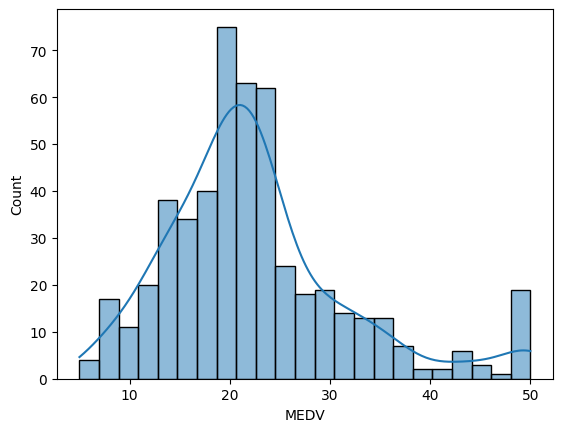

In [488]:
sns.histplot(df["MEDV"], kde = True)
df["MEDV"].skew()

##### checking whether the target distribution is skewed or normal (if skewed the predictions of the linear regression model can be negatively affected)

##### after using a histplot and .skew() , we observed that the target distribution is **positively skewed by 1.1080**

In [489]:
df["MEDV_log"] = np.log1p(df["MEDV"])

##### Since MEDV was positively skewed, we applied a log transformation (np.log1p) to make the distribution more symmetric.
##### This transformation reduces the impact of extreme high values and helps improve model performance.

np.float64(-0.23911835582000907)

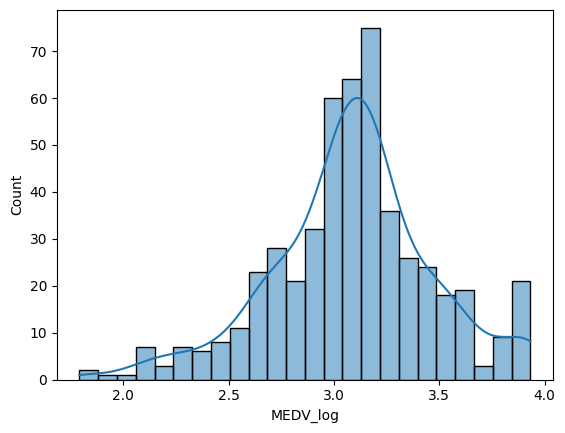

In [490]:
sns.histplot(df["MEDV_log"], kde = True)
df["MEDV_log"].skew()

##### to get rid of skewness we used **log transformation (y_log = log(1 + y))** this helps normalise and get rid of skewness.

##### after log transformation we can now see that **skewness = -0.2391** which means that distribution is close to **0 (Normal Distribution)**.

<Axes: >

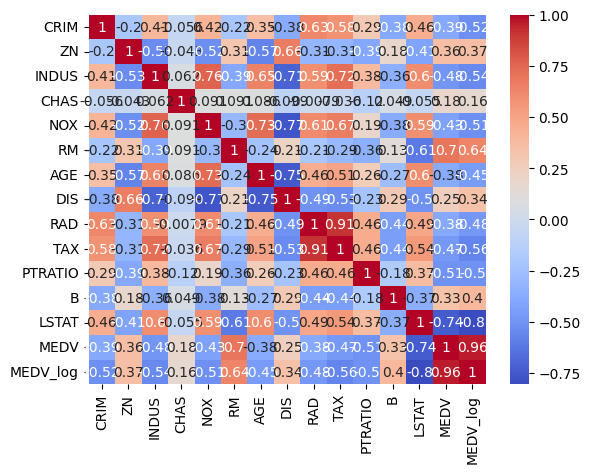

In [491]:
corr = df.corr()
sns.heatmap(corr, annot = True, cmap = "coolwarm")

##### we can observe above the correlation between different labels with the target value, but since there are too many labels it is too clumsy in the form of visualization.

In [492]:
corr_target = df.corr()["MEDV"].sort_values(ascending = True)
corr_target

LSTAT      -0.738187
PTRATIO    -0.508411
INDUS      -0.484126
TAX        -0.468543
NOX        -0.427295
CRIM       -0.388249
RAD        -0.381690
AGE        -0.376932
CHAS        0.175364
DIS         0.249896
B           0.333394
ZN          0.360393
RM          0.695365
MEDV_log    0.958249
MEDV        1.000000
Name: MEDV, dtype: float64

##### above we can observe the correlation in a better way and by that we can figure out that **LSTAT** & **PTRATIO** have **high negative correlation** and **RM**, **ZN**, & **B** have **high positive correlation**.

In [493]:
X = df[["RM","LSTAT","PTRATIO","ZN","B"]]
y = df["MEDV_log"]

##### assigning the best features and labels with better correlation.

### Model Building 

In [494]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train_log,y_test_log = train_test_split(X,y,random_state = 42)

##### using **train_test_split** from the scikitlearn library we are splittng the data into 2 seperate categories for - **training** & **testing**

In [495]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##### importing the Linear Regression model from Scikitlearn library

In [496]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##### assigning the model with the training data to generalize from

In [497]:
y_pred_log = model.predict(X_test)

##### predicting the results based up on the test data

In [498]:
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)

##### reverse transforming the log values into orginial so that we can evaluate the model performance using the original values

### Evaluation Metrics & Residual Analysis

In [499]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae = mean_absolute_error(y_test,y_pred,)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE : ", mae)
print("MSE : ", mse)
print("RMSE : ", rmse)
print("R2 : ", r2)

MAE :  3.108604692594465
MSE :  16.995954558820006
RMSE :  4.122615014626033
R2 :  0.7105985612818218


##### after evaluating the model on the test data we can observe that, 

###### MAE :  3.1 (The error between the actual vs predicted value is $3k)

###### RMSE : 4.1 (The model's predction is off by $4k)

###### R2 : 0.71 (Model is covering 71% variance of data)

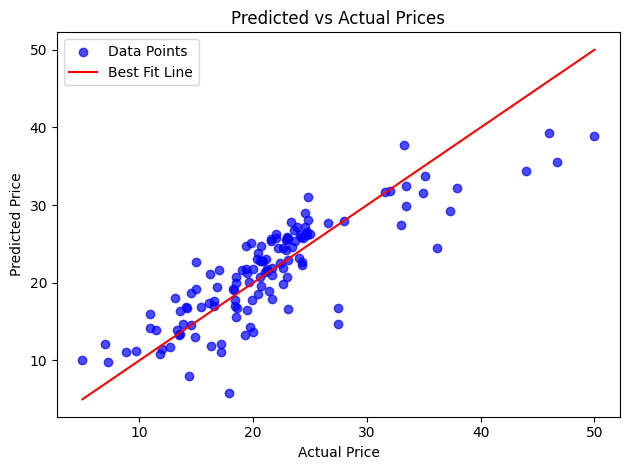

In [500]:
plt.scatter(x = y_test, y = y_pred, color = "blue", alpha = 0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color = "red", linestyle = "-")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.legend(["Data Points","Best Fit Line"])
plt.tight_layout()

##### This plot compares the actual house prices (x-axis) with the predicted prices (y-axis).
    - The blue points represent individual predictions.
    - The red line is the ideal line where predictions would perfectly match actual prices.
    - Most points are fairly close to the red line, which indicates that the model is performing reasonably well — capturing the overall trend, though there may still be some spread (errors).

Text(0.5, 1.0, 'Residuals vs Predicted Prices')

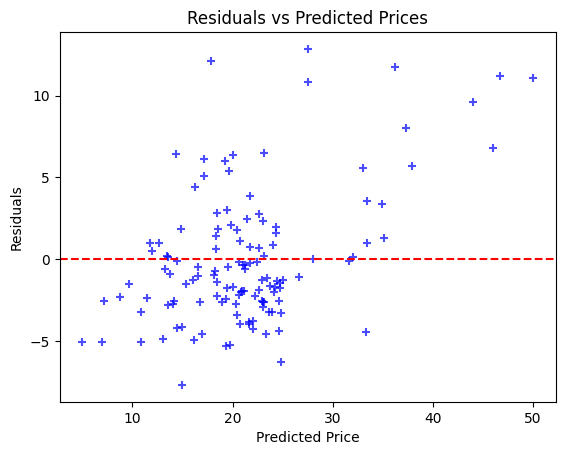

In [501]:
plt.scatter(x = y_test, y = y_test - y_pred, color = "blue", alpha = 0.7, marker = "+")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Prices")

##### This plot shows the residuals (errors) between the actual and predicted house prices.
    - The blue points represent the residuals for each prediction.
    - The red dashed line at 0 indicates perfect predictions (no error).

## Regularization

##### To reduce overfitting and improve model generalisation, I applied Ridge and Lasso regression:
    - Ridge Regression: Shrinks large coefficients but keeps all features.
    - Lasso Regression: Can shrink some coefficients to zero, effectively performing feature selection.


### Ridge L2 Regularization

In [502]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha = 1.0)
ridge_model.fit(X_train, y_train_log)
ridge_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae = mean_absolute_error(y_test,y_pred,)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE : ", mae)
print("MSE : ", mse)
print("RMSE : ", rmse)
print("R2 : ", r2)

MAE :  3.108604692594465
MSE :  16.995954558820006
RMSE :  4.122615014626033
R2 :  0.7105985612818218


##### The error metrics are almost the same as plain Linear Regression.
    - Ridge helped stabilise coefficients but didn’t drastically improve performance.
    - This suggests the dataset doesn’t have severe multicollinearity issues, so regularisation only had a marginal effect.

### Lasso L1 Regularization

In [503]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha = 1.0)
lasso_model.fit(X_train, y_train_log)
lasso_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae = mean_absolute_error(y_test,y_pred,)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE : ", mae)
print("MSE : ", mse)
print("RMSE : ", rmse)
print("R2 : ", r2)

MAE :  3.108604692594465
MSE :  16.995954558820006
RMSE :  4.122615014626033
R2 :  0.7105985612818218


##### The performance is almost identical to Ridge and plain Linear Regression.
    - Lasso is usually helpful in feature selection by shrinking some coefficients to zero, but in this case,                    it didn’t remove any features.
    - This indicates that all features might be contributing useful information to the model.

### Hyperparameter Tuning

##### To optimize the performance of Ridge and Lasso, I used GridSearchCV with 5-fold cross-validation.

In [504]:
from sklearn.model_selection import GridSearchCV

parameters = {"alpha" : [0.001, 0.01, 0.1, 1.0, 1.5, 2, 3, 4, 5]}
ridgecv = GridSearchCV(ridge_model, parameters,scoring = "neg_mean_squared_error", cv = 5)
ridgecv.fit(X_train,y_train_log)

ridgecv = GridSearchCV(lasso_model, parameters, scoring = "neg_mean_squared_error", cv = 5)
ridgecv.fit(X_train,y_train_log)

,estimator,Lasso()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.001


In [505]:
print(ridgecv.best_params_)
print(ridgecv.best_score_)

{'alpha': 0.001}
-0.03996775969499537


In [506]:
lassocv = GridSearchCV(lasso_model, parameters, scoring = "neg_mean_squared_error", cv = 5)
lassocv.fit(X_train,y_train_log)

,estimator,Lasso()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.001


In [507]:
print(lassocv.best_params_)
print(lassocv.best_score_)

{'alpha': 0.001}
-0.03996775969499537


    - Both Ridge and Lasso selected very low α (0.001) → minimal regularization works best.
    - Cross-validation errors are reported on log-transformed target (so values look small).
    - Regularization didn’t significantly change model performance compared to plain Linear Regression.